In [18]:
import pandas as pd   
import numpy as np     
import matplotlib.pyplot as plt    
#First we are going to load Housing dataset
df=pd.read_csv("Housing.csv")
#Now check if any column has null values
print(df.isnull().sum())
#Print first five rows of dataset to view insights
df.head()    
#print list of columns
# print(f'Columns of Dataset:{df.columns.to_list()}')


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Feature Engineering of price column.

In [19]:
df['PricePerArea']=df['price']/df['area']
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'PricePerArea']


Now check outliers in a Dataset.(Outliers are those values which are below minimum range or above maximum range)

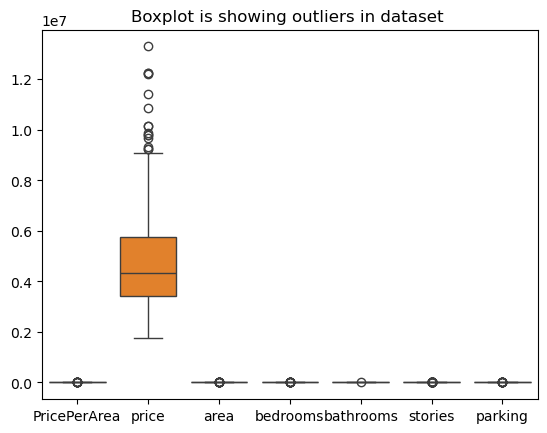

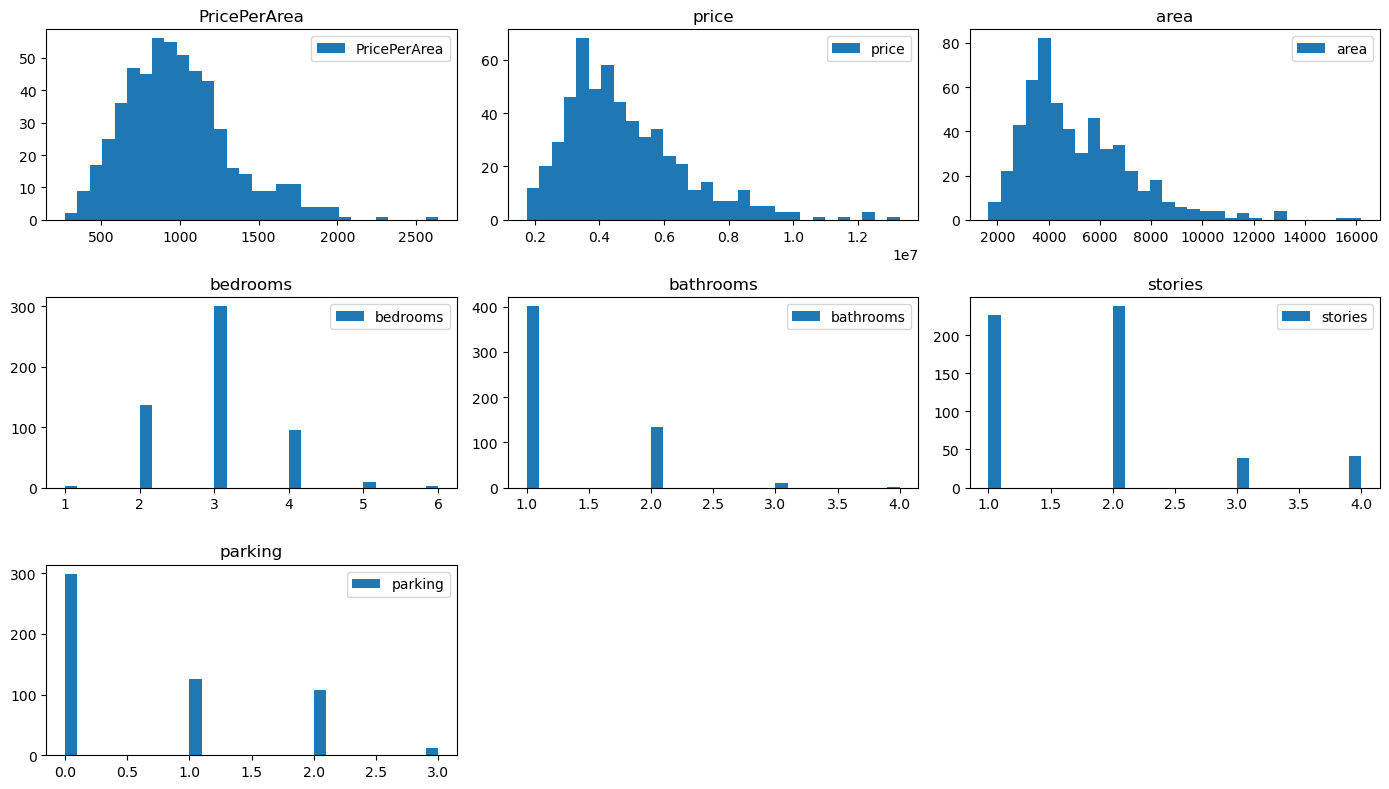

In [20]:
import seaborn as sns   
#tocheck outliers we use Boxplot to show outliers in numerical columns
sns.boxplot(data=df[['PricePerArea','price','area','bedrooms', 'bathrooms', 'stories', 'parking']])
plt.title("Boxplot is showing outliers in dataset ")
plt.show()
#as outliers exists in dataframe. so we have to check which technique of removing outliers should I use
#as techniques are available IQR or Z-Score. For normally distributed data we use Z-score and for skewed data
#we use IQR Method to remove outliers in data.
numerical_cols=['PricePerArea','price','area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df[numerical_cols].hist(bins=30,grid=False,figsize=(14,8),legend=True)
plt.tight_layout()

To Remove outliers from Dataset we have to use IQR method as numerical columns of outliers are not normally distributed.

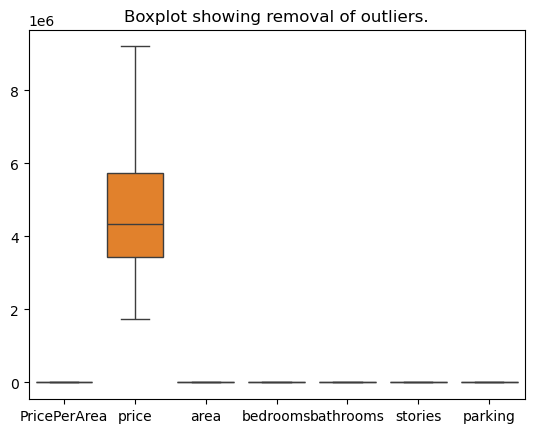

In [21]:
#Removal of outliers by using InterQuartileRange method.
def remove_outliers(df,col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    #now perform capping instead of removal of outliers from dataframe 
    df[col]=df[col].clip(lower_bound,upper_bound)
    return df

numerical_cols=['PricePerArea','price','area', 'bedrooms', 'bathrooms', 'stories', 'parking']
for col in numerical_cols:
    df=remove_outliers(df,col)

#Now check is thers is outliers exists in data
sns.boxplot(data=df[['PricePerArea','price','area', 'bedrooms', 'bathrooms', 'stories', 'parking']])
plt.title("Boxplot showing removal of outliers.")
plt.show()

Now WE are going to perform One Hot Encoding on Nominal Data as Furnishing status has nominal data where there is no positioning or order or ranking

In [22]:
df=pd.get_dummies(data=df,columns=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'])
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'PricePerArea', 'mainroad_no', 'mainroad_yes', 'guestroom_no', 'guestroom_yes', 'basement_no', 'basement_yes', 'hotwaterheating_no', 'hotwaterheating_yes', 'airconditioning_no', 'airconditioning_yes', 'prefarea_no', 'prefarea_yes', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


Now select Features and Label column to trian ML Model.

In [26]:

X = df.drop(['price', 'PricePerArea'], axis=1)
y = df['price']
y = np.log1p(y)


NOW we are going to perform scaling on training and testing data 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,)

scaler=StandardScaler()
# Fit and Tranform training data
X_train_scaled=scaler.fit_transform(X_train)
#Transform only for testing data
X_test_scaled=scaler.transform(X_test)
model=LinearRegression()
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)
# Convert back from log
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2score = r2_score(y_test_original, y_pred_original)

print(f'MAE: using Linear Regression {mae}')
print(f'MSE: using Linear Regression {mse}')
print(f'RMSE: using Linear Regression {rmse}')
print(f'R²:using Linear Regression {r2score}')





MAE: 845105.582050028
MSE: 1235900621506.3647
RMSE: 1111710.6734696599
R²: 0.6572981746484742


Training using Gradient Boosting

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,)

scaler=StandardScaler()
# Fit and Tranform training data
X_train_scaled=scaler.fit_transform(X_train)
#Transform only for testing data
X_test_scaled=scaler.transform(X_test)
model=GradientBoostingRegressor()
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)
# Convert back from log
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2score = r2_score(y_test_original, y_pred_original)

print(f'MAE: Using Gradient Boosting  {mae}')
print(f'MSE: Using Gradient Boosting {mse}')
print(f'RMSE:Using Gradient Boosting {rmse}')
print(f'R²:Using Gradient Boosting {r2score}')


MAE: 829284.1528265683
MSE: 1173119221366.295
RMSE: 1083106.2835042067
R²: 0.6747067753496396
